In [87]:
%load_ext autoreload
%autoreload 2

# 3rd party imports
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
np.set_printoptions(linewidth=1000)

from scipy.optimize import minimize, LinearConstraint, NonlinearConstraint
from scipy.ndimage import uniform_filter


# Local imports
import modules.laplacian as laplacian
import modules.jacobian as jacobian
import modules.correspondences as correspondences

import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
# define global booleans
jacobian_threshold = 0.0
max_iterations = 50

In [89]:
# Define global var

list_dev = []
num_neg_jac_init = []
num_neg_jac = []
time_taken = []
full_start = time.time()

## Using heuristic

In [90]:
# jacobian functions

def jacobian_det2D(phi_xy):
    deformation = np.zeros((3,1, *phi_xy.shape[-2:]))
    deformation[2] = phi_xy[1]
    deformation[1] = phi_xy[0]
    return jacobian.sitk_jacobian_determinant(deformation)

In [91]:
def non_smoothness(phi):
    """
    Returns a (rows, cols) matrix indicating how different each pixel's deformation is
    from the average of its neighbors.
    """
    # Compute local averages using a 3x3 uniform filter (ignores edges)
    avg_phi_y = uniform_filter(phi[0], size=3, mode='reflect')
    avg_phi_x = uniform_filter(phi[1], size=3, mode='reflect')

    # Difference from local average
    diff_y = phi[0] - avg_phi_y
    diff_x = phi[1] - avg_phi_x

    # Compute L2 norm of the vector difference
    return np.sqrt(diff_y**2 + diff_x**2)

def non_smoothness_per_idx(phi, idx):
    """
    Returns the non-smoothness scalar value at a single pixel (idx_y, idx_x).
    """
    idx_y, idx_x = idx
    neighborhood = phi[:, max(0, idx_y-1):idx_y+2, max(0, idx_x-1):idx_x+2]

    # Skip if there's no neighborhood (corner case)
    if neighborhood.shape[1] < 2 or neighborhood.shape[2] < 2:
        return 0.0

    avg_y = neighborhood[0].mean()
    avg_x = neighborhood[1].mean()

    diff_y = phi[0, idx_y, idx_x] - avg_y
    diff_x = phi[1, idx_y, idx_x] - avg_x

    return np.sqrt(diff_y**2 + diff_x**2)

def replace_deformation(phi, idx_y, idx_x):
    """
    Returns the average deformation vector (y_val, x_val) around the pixel at (idx_y, idx_x).
    """
    y_start = max(0, idx_y - 1)
    y_end   = min(phi.shape[1], idx_y + 2)
    x_start = max(0, idx_x - 1)
    x_end   = min(phi.shape[2], idx_x + 2)

    neighborhood_y = phi[0, y_start:y_end, x_start:x_end]
    neighborhood_x = phi[1, y_start:y_end, x_start:x_end]

    # Optionally exclude the center pixel from the average
    mask = np.ones_like(neighborhood_y, dtype=bool)
    center_y = idx_y - y_start
    center_x = idx_x - x_start
    mask[center_y, center_x] = False

    avg_y = neighborhood_y[mask].mean()
    avg_x = neighborhood_x[mask].mean()

    return avg_y, avg_x

In [92]:
def correct_using_heuristic(deformation_i):
    '''
    1. compute jac everywhere
    2. if neg jac and < max_iter - compute non-smoothness and sort in dec order
    3. change the first one to avg of surroundings
    4. repeat
    5. keep track of num_neg_jacs at each stage, jacobian matrix, index of point that was modified
    '''
    slice_shape = (1, *deformation_i.shape[-2:])

    # this phi will be updated iteratively
    phi = np.zeros((2, *deformation_i.shape[-2:]))
    phi[1] = deformation_i[-1]
    phi[0] = deformation_i[-2]
    print(f'deformation_i shape: {deformation_i.shape}, phi_init shape: {phi.shape}')
    phi_init = phi.copy()

    # set threshold for Jacobian and store results

    jacobians = []
    num_neg_jac_per_iter = []
    tot_start = time.time()

    # collect indices with -ve Jacobians into a list in a sorted fashion
    jacobian_matrix = jacobian_det2D(phi)
    jacobians.append(jacobian_matrix.copy())
    num_neg_jac_per_iter.append((jacobian_det2D(phi)<0).sum())

    iter = 0

    while iter < max_iterations and (jacobian_matrix < jacobian_threshold).any():
        non_smoothness_values = non_smoothness(phi)
        
        # find index of pixel with max value in non_smoothness_values
        idx_y, idx_x = np.unravel_index(np.argmax(non_smoothness_values), non_smoothness_values.shape)
        y_val, x_val = replace_deformation(phi, idx_y, idx_x)
        phi[0, idx_y, idx_x] = y_val
        phi[1, idx_y, idx_x] = x_val

        jacobian_matrix = jacobian_det2D(phi)
        jacobians.append(jacobian_matrix.copy())
        num_neg_jac_per_iter.append((jacobian_det2D(phi)<0).sum())

        iter += 1
    

    # compute errors - 2-norm between phi and phi_init
    deviation = np.linalg.norm(phi - phi_init)


    tot_end = time.time()


    # add to global var list
    list_dev.append(deviation)
    num_neg_jac_init.append((jacobian_det2D(phi_init)<0).sum())
    num_neg_jac.append((jacobian_det2D(phi)<0).sum())
    time_taken.append(tot_end-tot_start)
    
    print(f'Reduced to {(jacobian_det2D(phi)<0).sum()} from {(jacobian_det2D(phi_init)<0).sum()} -ve jacobians.')
    print(f'Deviation {deviation} in {tot_end-tot_start}s')

    return phi, jacobians, num_neg_jac_per_iter
    

## preprocessing and plotting methods

In [93]:
def plot_deformations(msample, fsample, deformation_i, phi_corrected, figsize=(10,10)):
    jacobian_initial = jacobian_det2D(deformation_i[1:])
    jacobian_final = jacobian_det2D(phi_corrected)

    # print("JACOBIAN SHAPES", jacobian_initial.shape, jacobian_final.shape)

    # Create DataFrame
    data = {
        ("x-def", "min"): [np.min(deformation_i[2,0]), np.min(phi_corrected[1])],
        ("x-def", "max"): [np.max(deformation_i[2,0]), np.max(phi_corrected[1])],
        ("y-def", "min"): [np.min(deformation_i[1,0]), np.min(phi_corrected[0])],
        ("y-def", "max"): [np.max(deformation_i[1,0]), np.max(phi_corrected[0])],
        ("jacobian", "min"): [np.min(jacobian_initial), np.min(jacobian_final)],
        ("jacobian", "max"): [np.max(jacobian_initial), np.max(jacobian_final)]
    }

    row_names = ["initial", "final"]
    df = pd.DataFrame(data, index=row_names)

    # Print table
    print(df)


    # plot initial vs final Jacobian
    norm = mcolors.TwoSlopeNorm(vmin=min(jacobian_initial.min(), jacobian_final.min(), -1), vcenter=0, vmax=max(jacobian_initial.max(), jacobian_final.max(), 1))


    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=figsize)

    # jacobians are of shape (1,5,5). Use index [0] for 2D plots
    im0 = axs[0,0].imshow(jacobian_initial[0], cmap='seismic', norm=norm, interpolation='nearest')
    im1 = axs[0,1].imshow(jacobian_final[0], cmap='seismic', norm=norm, interpolation='nearest')

    for i in range(len(msample)):  # Draw lines connecting the points
        axs[0,0].annotate(
            '', 
            xy=(fsample[i][2], fsample[i][1]), 
            xytext=(msample[i][2], msample[i][1]), 
            arrowprops=dict(facecolor='black', shrink=0.045, headwidth=8, headlength=10, width=3)
        )
    
    # Create a grid of points
    x, y = np.meshgrid(range(deformation_i.shape[3]), range(deformation_i.shape[2]), indexing='xy')
    print(f'meshgrid shape for plot: {x.shape}')
    
    axs[0,0].set_title('Initial J det')
    axs[0,0].scatter(msample[:, 2], msample[:, 1], c='g', label='Moving')
    axs[0,0].scatter(fsample[:, 2], fsample[:, 1], c='violet', label='Fixed')
    axs[0,0].legend()

    axs[0,1].set_title('final J det')

    axs[1,0].set_title('Initial deformation')
    axs[1,0].quiver(x, y, -deformation_i[2,0], deformation_i[1,0])

    axs[1,1].set_title('final deformation')
    axs[1,1].quiver(x, y, -phi_corrected[1], phi_corrected[0])

    for i in range(2):
        axs[1,i].invert_yaxis()
    
    #fig.subplots_adjust(right=0.8)
    cax = fig.add_axes([0.95, 0.5, 0.02, 0.4])
    fig.colorbar(im1, cax=cax)
    plt.show()

In [94]:
def plot_jacobians_iteratively(jacobians, msample, fsample, methodName='SLSQP'):
    # assume jacobians is a list of numpy arrays of shape (1, 5, 5)
    # assume msample and fsample are (N, 3) arrays

    num_jacobians = len(jacobians)
    ncols = min(2, num_jacobians)  # wrap at 2 columns
    nrows = (num_jacobians + ncols - 1) // ncols  # ceiling division

    # Compute color normalization
    all_vals = [j[0] for j in jacobians]  # extract 2D arrays from (1,5,5)
    vmin = min(j.min() for j in all_vals)
    vmax = max(j.max() for j in all_vals)
    norm = mcolors.TwoSlopeNorm(vmin=min(vmin, -1), vcenter=0, vmax=max(vmax, 1))

    # Create subplots
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
    axs = axs.flatten()

    for i, jac in enumerate(jacobians):
        im = axs[i].imshow(jac[0], cmap='seismic', norm=norm, interpolation='nearest')
        num_negs = np.sum(jac <= 0)
        axs[i].set_title(f'Jacobian #{i}, {num_negs} -ves' if i > 0 else f'Initial J det: {num_negs} -ves')

        if i == 0:
            axs[i].scatter(msample[:, 2], msample[:, 1], c='g', label='Moving', s=10)
            axs[i].scatter(fsample[:, 2], fsample[:, 1], c='violet', label='Fixed', s=10)
            axs[i].legend()

    for i in range(len(msample)):  # Draw lines connecting the points
        axs[0].annotate(
            '', 
            xy=(fsample[i][2], fsample[i][1]), 
            xytext=(msample[i][2], msample[i][1]), 
            arrowprops=dict(facecolor='black', shrink=0.1, headwidth=3, headlength=5, width=1)
        )

    # Hide any extra axes
    for j in range(len(jacobians), len(axs)):
        axs[j].axis('off')

    # Add colorbar
    # cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    # fig.colorbar(im, cax=cax)
    fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

def run_lapl_and_correction(fixed_sample, msample, fsample, methodName='SLSQP'):
    '''plot each Jacobian matrix'''
    deformation_i, A, Zd, Yd, Xd = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)
    print(f'deformation shape: {deformation_i.shape}')
    phi_corrected, jacobians, num_neg_jac_per_iter = correct_using_heuristic(deformation_i)
    print(f'Number of negative jacobians per iteration: {num_neg_jac_per_iter}')
    #plot_jacobians_iteratively(jacobians, msample, fsample, methodName='SLSQP')
    plot_deformations(msample, fsample, deformation_i, phi_corrected, figsize=(10,10))

## Some more testcases

deformation shape: (3, 1, 20, 40)
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 12 -ve jacobians.
Deviation 6.209310047336316 in 0.05205178260803223s
Number of negative jacobians per iteration: [12, 11, 10, 9, 8, 7, 6, 6, 6, 5, 5, 5, 4, 4, 4, 3, 1, 1, 1, 0]
            x-def           y-def            jacobian          
              min       max   min       max       min       max
initial -4.999267  8.998681   0.0  1.998764 -1.150262  2.877145
final   -2.957849  6.241832   0.0  1.365391  0.058379  1.764115
meshgrid shape for plot: (20, 40)


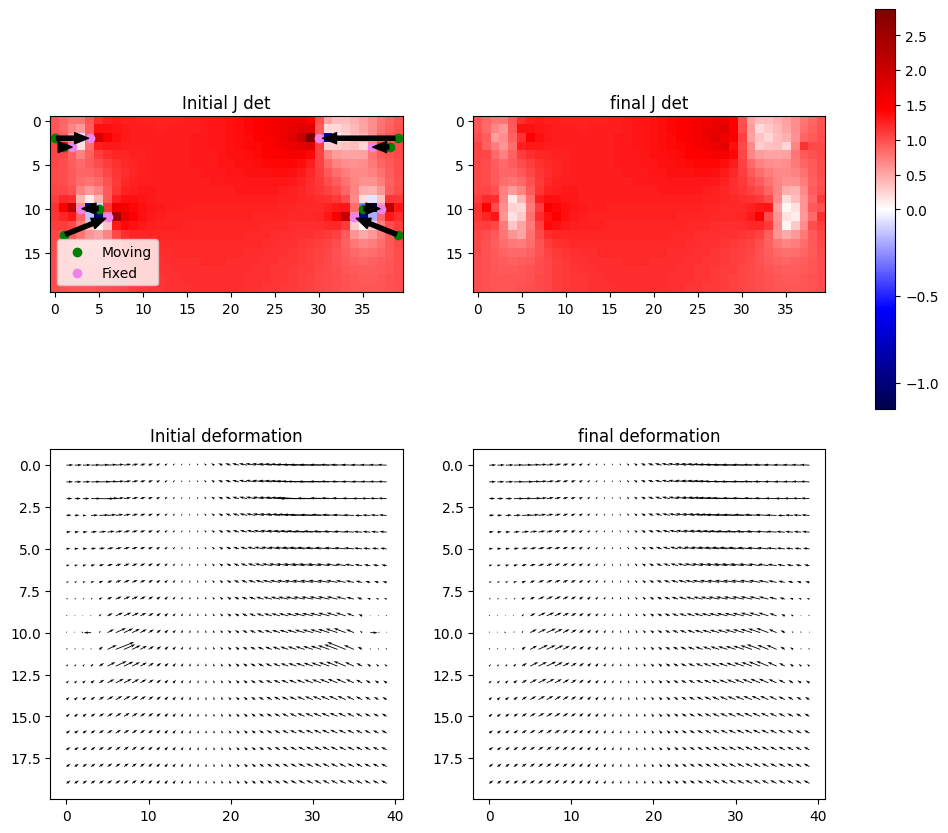

In [95]:
msample = np.array([
    [0, 2, 0],
    [0, 3, 1],
    [0, 10, 5],
    [0, 13, 1],
    [0, 2, 39],
    [0, 3, 38],
    [0, 10, 35],
    [0, 13, 39],
])
fsample = np.array([
    [0, 2, 4],
    [0, 3, 2],
    [0, 10, 3],
    [0, 11, 6],
    [0, 2, 30],
    [0, 3, 36],
    [0, 10, 37],
    [0, 11, 34]
])

fixed_sample = np.zeros((1, 20, 40))

run_lapl_and_correction(fixed_sample, msample, fsample)

deformation shape: (3, 1, 20, 40)
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 150 from 158 -ve jacobians.
Deviation 12.948552191012604 in 0.11255002021789551s
Number of negative jacobians per iteration: [158, 158, 158, 158, 158, 158, 158, 158, 158, 158, 158, 158, 157, 157, 157, 157, 157, 156, 156, 157, 156, 156, 156, 156, 156, 155, 154, 154, 155, 154, 153, 153, 154, 153, 152, 151, 150, 149, 148, 148, 148, 149, 149, 149, 150, 150, 150, 150, 150, 150, 150]
             x-def                 y-def            jacobian          
               min        max        min       max       min       max
initial -19.976474  19.976474 -10.001746 -9.289016 -3.369923  4.326747
final   -13.530393  13.170639  -9.808494 -9.289016 -0.683750  1.585628
meshgrid shape for plot: (20, 40)


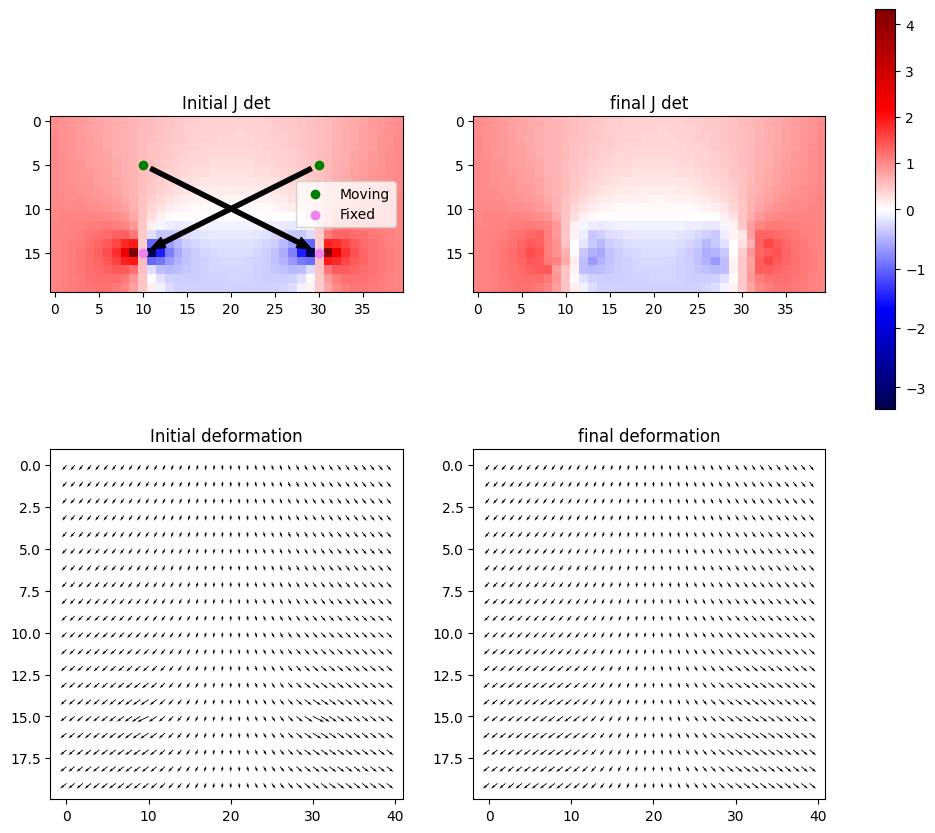

In [96]:
msample = np.array([
    [0, 5, 10],
    [0, 5, 30],
])
fsample = np.array([
    [0, 15, 30],
    [0, 15, 10],
])

fixed_sample = np.zeros((1, 20, 40))

run_lapl_and_correction(fixed_sample, msample, fsample)

# 600 iterations
# 83min - final size 9x9

deformation shape: (3, 1, 20, 40)
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 16 from 28 -ve jacobians.
Deviation 9.486152754473682 in 0.09304499626159668s
Number of negative jacobians per iteration: [28, 28, 28, 27, 28, 26, 26, 26, 25, 25, 24, 24, 23, 23, 22, 22, 21, 21, 21, 21, 21, 21, 21, 21, 21, 20, 21, 21, 21, 21, 21, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 19, 19, 18, 18, 18, 18, 18, 17, 16]
             x-def                 y-def             jacobian          
               min        max        min        max       min       max
initial -19.998859 -17.782671 -10.001314  10.001314 -2.028319  3.164794
final   -19.482464 -17.782671  -5.230322   4.793884 -0.184514  1.252675
meshgrid shape for plot: (20, 40)


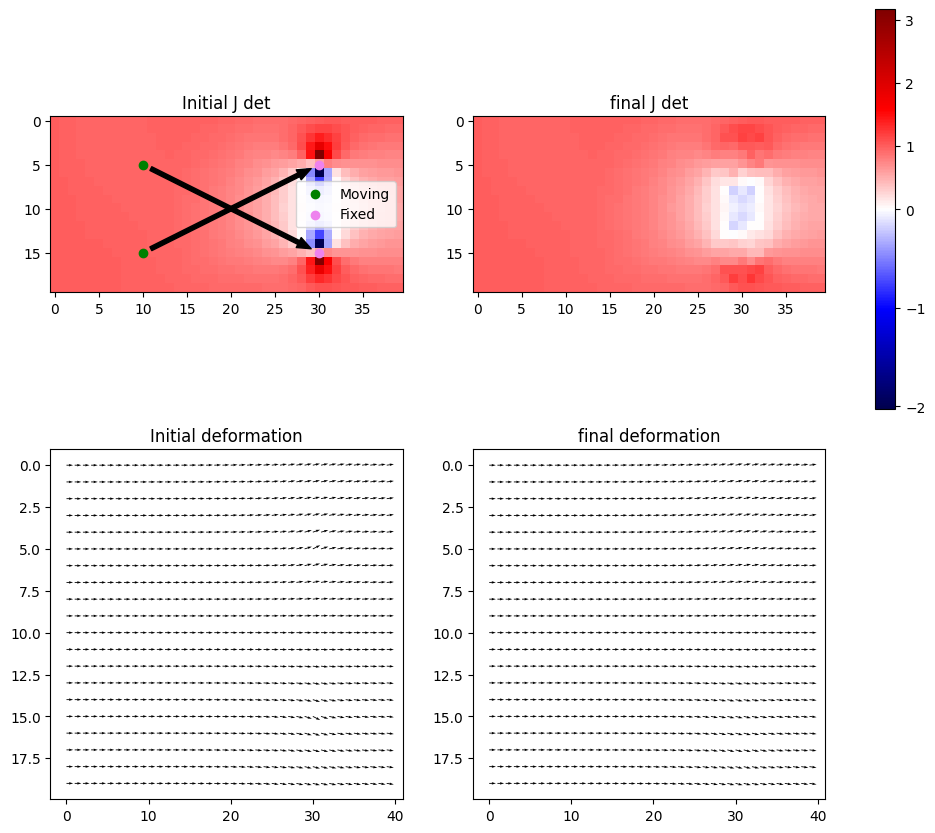

In [97]:
msample = np.array([
    [0, 5, 10],
    [0, 15, 10],
])
fsample = np.array([
    [0, 15, 30],
    [0, 5, 30],
])

fixed_sample = np.zeros((1, 20, 40))

run_lapl_and_correction(fixed_sample, msample, fsample)

deformation shape: (3, 1, 20, 40)
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 150 from 158 -ve jacobians.
Deviation 12.948552191012604 in 0.08539414405822754s
Number of negative jacobians per iteration: [158, 158, 158, 158, 158, 158, 158, 158, 158, 158, 158, 158, 157, 157, 157, 157, 157, 156, 156, 157, 156, 156, 156, 156, 156, 155, 154, 154, 155, 154, 153, 153, 154, 153, 152, 151, 150, 149, 148, 148, 148, 149, 149, 149, 150, 150, 150, 150, 150, 150, 150]
             x-def                 y-def            jacobian          
               min        max        min       max       min       max
initial -19.976474  19.976474 -10.001746 -9.289016 -3.369923  4.326747
final   -13.530393  13.170639  -9.808494 -9.289016 -0.683750  1.585628
meshgrid shape for plot: (20, 40)


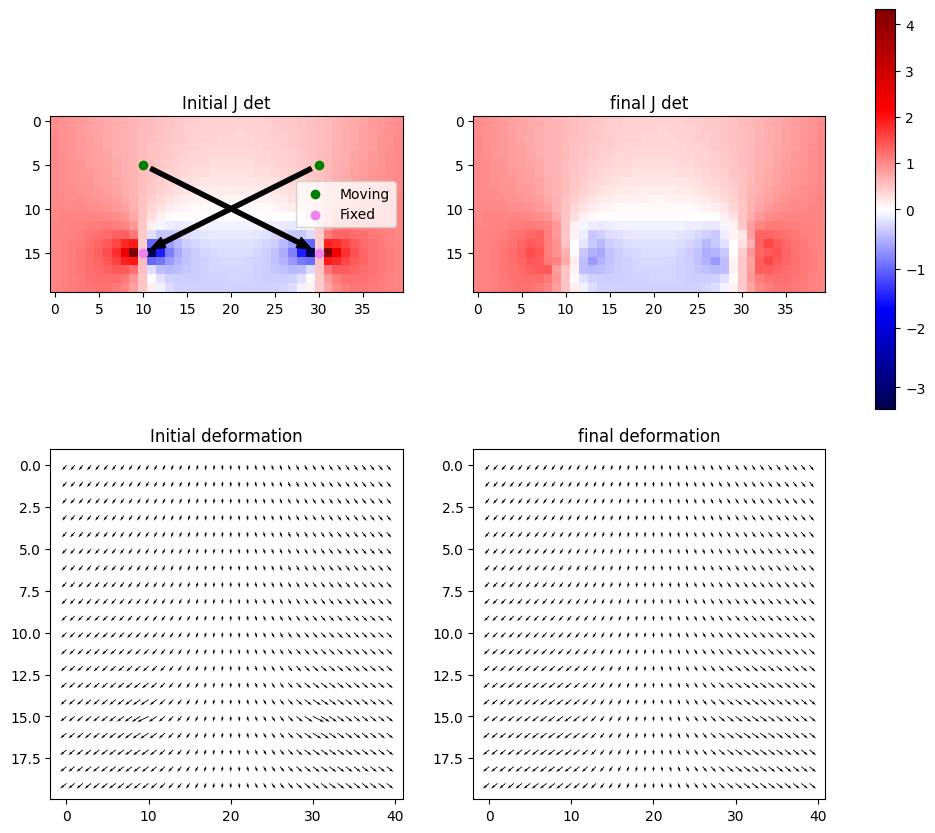

In [98]:
msample = np.array([
    [0, 5, 10],
    [0, 5, 30],
])
fsample = np.array([
    [0, 15, 30],
    [0, 15, 10],
])

fixed_sample = np.zeros((1, 20, 40))

run_lapl_and_correction(fixed_sample, msample, fsample)

# not all iterations take the same time?
# Iter 1 Optimisation for index 611 completed in 0.7802479267120361s
# Iter 635 Optimisation for index 693 completed in 278.3064708709717s
# Iter 573 Optimisation for index 494 completed in 63.11005783081055s
# total time 175m - unfinished

deformation shape: (3, 1, 20, 40)
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 4 from 29 -ve jacobians.
Deviation 11.185462304919913 in 0.10350370407104492s
Number of negative jacobians per iteration: [29, 28, 26, 26, 24, 22, 20, 19, 18, 18, 17, 15, 14, 13, 13, 12, 12, 12, 12, 12, 12, 12, 11, 11, 11, 10, 10, 10, 8, 8, 8, 8, 8, 8, 7, 6, 6, 6, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4]
            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial -6.999377  4.999555 -4.999602  3.999682 -1.343039  4.142665
final   -3.084935  3.558621 -3.650890  2.149339 -0.086220  1.865550
meshgrid shape for plot: (20, 40)


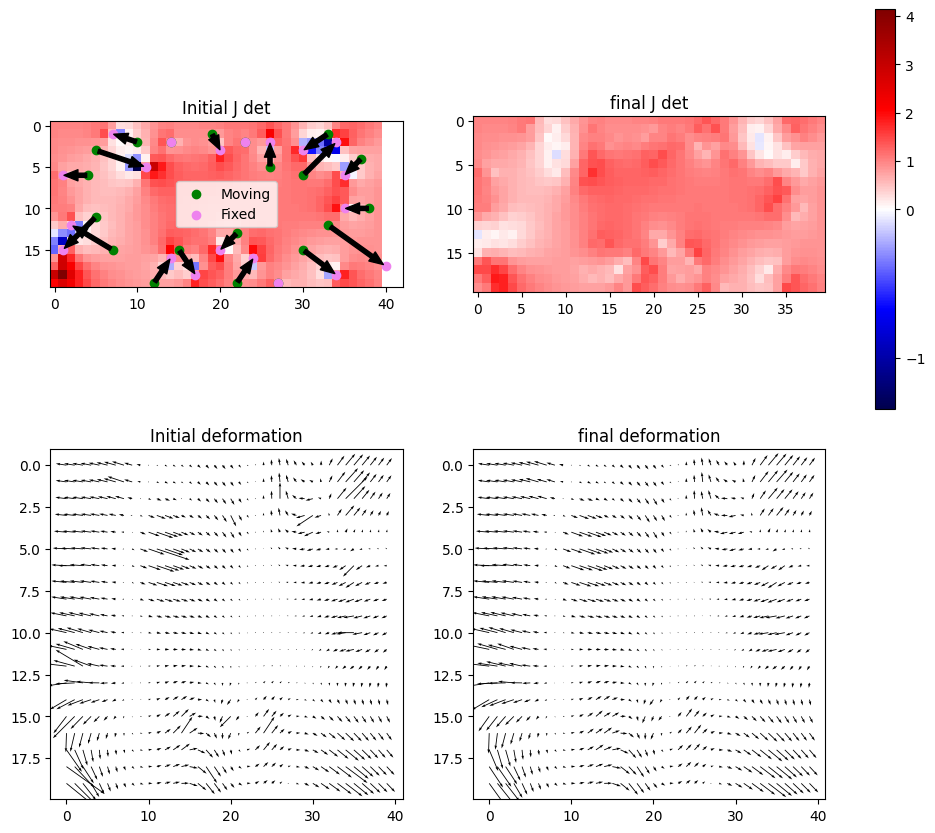

In [99]:
msample = np.array([
    [0, 2, 10],
    [0, 3, 5],
    [0, 6, 4],
    [0, 11, 5],
    [0, 15, 7],
    [0, 19, 12],
    [0, 15, 15],
    [0, 13, 22],
    [0, 19, 22],
    [0, 19, 27],
    [0, 15, 30],
    [0, 12, 33],
    [0, 10, 38],
    [0, 4, 37],
    [0, 6, 30],
    [0, 1, 33],
    [0, 5, 26],
    [0, 2, 23],
    [0, 1, 19],
    [0, 2, 14],
])
fsample = np.array([
    [0, 1, 7],
    [0, 5, 11],
    [0, 6, 1],
    [0, 15, 1],
    [0, 12, 2],
    [0, 16, 14],
    [0, 18, 17],
    [0, 15, 20],
    [0, 16, 24],
    [0, 19, 27],
    [0, 18, 34],
    [0, 17, 40],
    [0, 10, 35],
    [0, 6, 35],
    [0, 2, 34],
    [0, 3, 30],
    [0, 2, 26],
    [0, 2, 23],
    [0, 3, 20],
    [0, 2, 14],
])

fixed_sample = np.zeros((1, 20, 40))

run_lapl_and_correction(fixed_sample, msample, fsample)

## Testcases

deformation shape: (3, 1, 10, 10)
deformation_i shape: (3, 1, 10, 10), phi_init shape: (2, 10, 10)
Reduced to 0 from 5 -ve jacobians.
Deviation 2.960600589754988 in 0.011211156845092773s
Number of negative jacobians per iteration: [5, 3, 2, 2, 1, 0]
            x-def           y-def       jacobian          
              min       max   min  max       min       max
initial -2.999822  2.999822   0.0  0.0 -0.730373  1.709059
final   -1.967781  0.877175   0.0  0.0  0.044456  1.288718
meshgrid shape for plot: (10, 10)


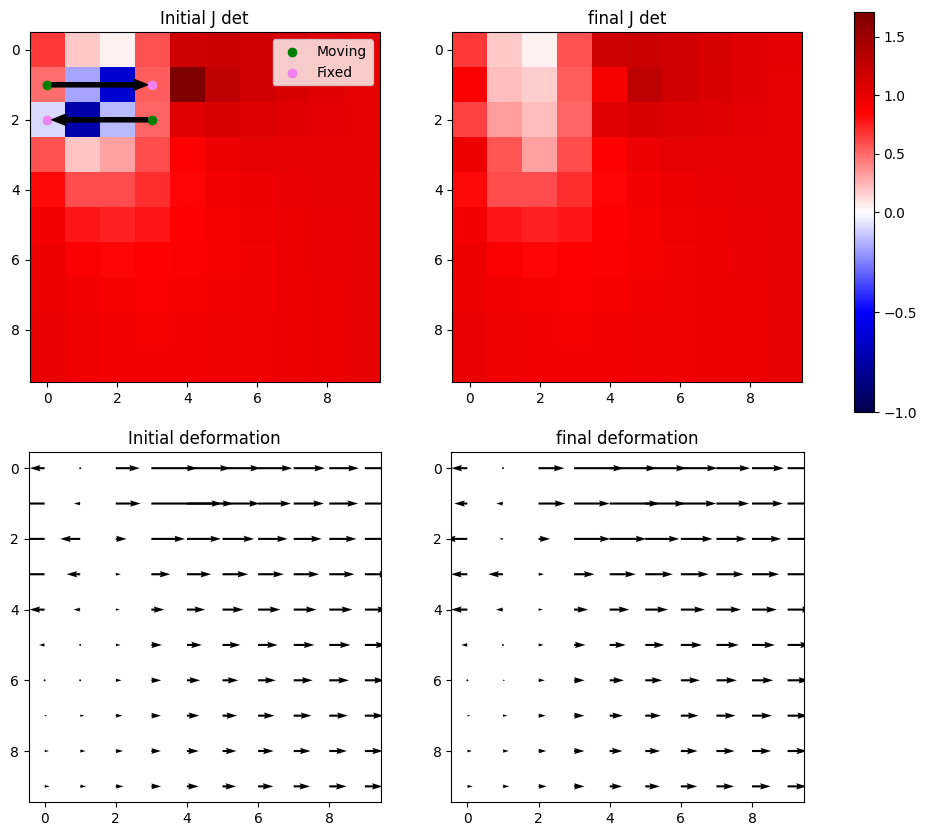

In [100]:
msample = np.array([
    [0, 1, 0],
    [0, 2, 3],
])
fsample = np.array([
    [0, 1, 3],
    [0, 2, 0],
])

fixed_sample = np.zeros((1, 10, 10)) # depth, rows, cols

run_lapl_and_correction(fixed_sample, msample, fsample)

# takes 15 mins and does not conclude on full 20x40 constraints
# 1.5mins on 10x10 constraints
# reduce constraints
# (10,5) - 50 vs 5 - 3.9s vs 0.15s
# (5,5) - 25 vs 5 - 0.35s vs 0.0645s
# (10, 10) - 100 vs 5 - 50s vs 0.46s
# (20, 20) - 400 vs 5 - waited for full one to run for 20min vs 1.5min

# 20x40 with 5 random constraints - 10.5 mins
# 20x40 run over the full thing - 174 min does not finish

deformation shape: (3, 1, 10, 10)
[[[[ 0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
   [ 0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
   [ 0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
   [ 0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
   [ 0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
   [ 0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
   [ 0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
   [ 0.          0.          0.          0.          0.          0.          0.          0.

/var/folders/pj/ny1dgkl90cj0mpph_t0mvd000000gn/T/ipykernel_48226/1299528067.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


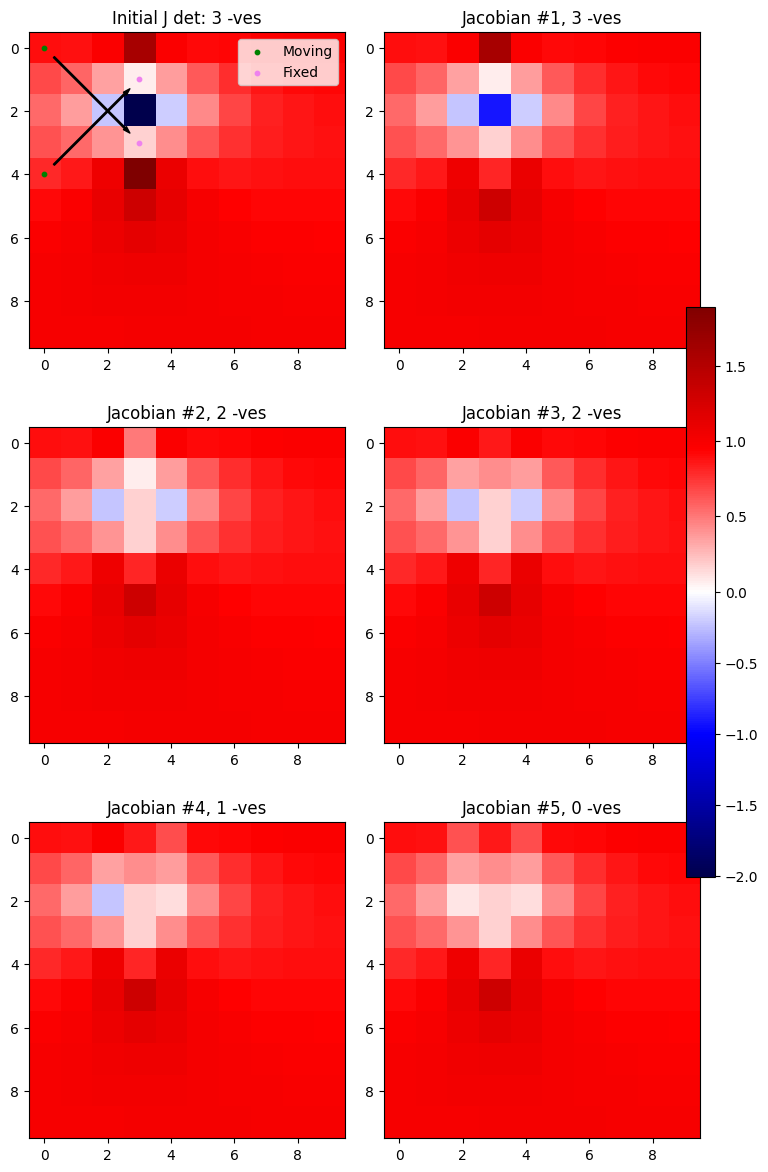

            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial -3.013711 -2.977314 -2.999803  2.999803 -2.003395  1.893126
final   -3.013711 -2.977314 -1.661573  1.297173  0.095107  1.310257
meshgrid shape for plot: (10, 10)


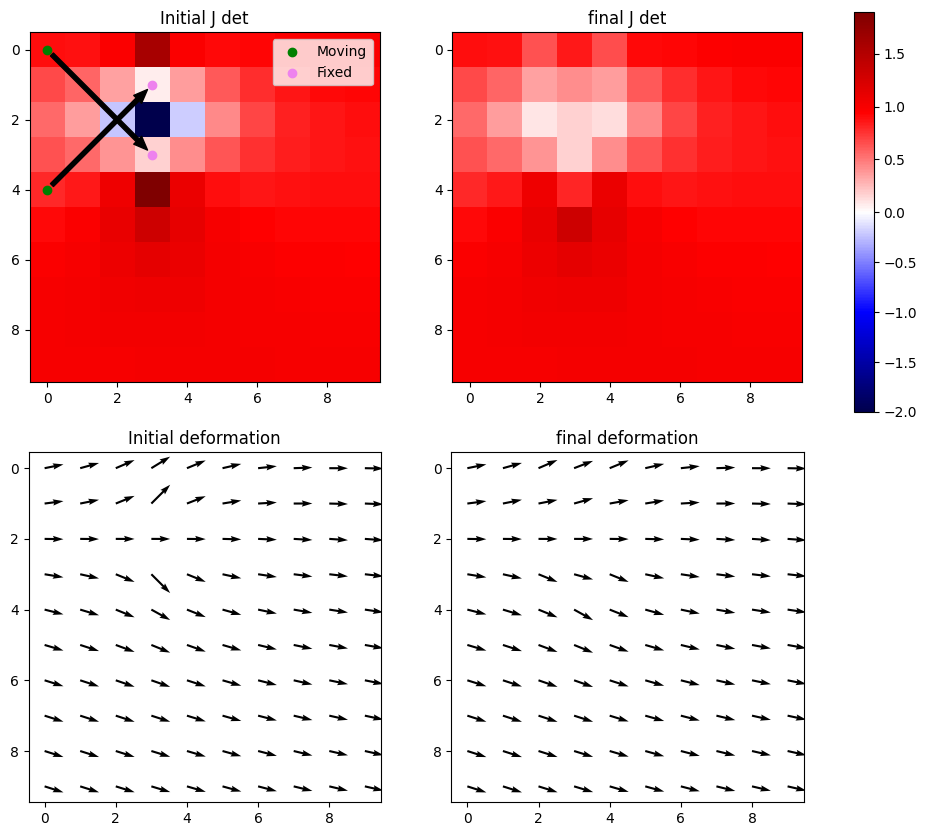

[[[ 0.89126076  0.88649201  0.96400756  1.58394211  0.97360102  0.9065901   0.92879864  0.95207293  0.96609706  0.97211199]
  [ 0.67434955  0.56825474  0.34437072  0.07246907  0.36555203  0.62007237  0.77637465  0.86184539  0.90500563  0.9221917 ]
  [ 0.56162551  0.36726659 -0.22374717 -2.0033955  -0.19642219  0.43519678  0.69436959  0.81377889  0.86940417  0.89126523]
  [ 0.64182308  0.56192132  0.39110896  0.17568873  0.42200789  0.62541714  0.75434954  0.82965913  0.86984911  0.88682344]
  [ 0.79774359  0.84437209  1.05607877  1.8931261   1.08067768  0.891393    0.86707284  0.88018585  0.89376049  0.90111237]
  [ 0.90823824  0.96275502  1.09845439  1.31025733  1.11602031  0.99152123  0.94040463  0.92541182  0.92359339  0.92360827]
  [ 0.96695629  1.00323031  1.0688907   1.13056668  1.07980755  1.01723224  0.97693277  0.95788151  0.95005035  0.94618935]
  [ 0.99279104  1.01131422  1.04144231  1.06487086  1.05026458  1.02040474  0.99527376  0.97920474  0.97058169  0.96548345]
  [ 1.00

In [101]:
msample = np.array([
    [0, 0, 0],
    [0, 4, 0],
])
fsample = np.array([
    [0, 3, 3],
    [0, 1, 3],
])

fixed_sample = np.zeros((1, 10, 10))
#run_lapl_and_correction(fixed_sample, msample, fsample)
deformation_i, A, Zd, Yd, Xd = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)
print(f'deformation shape: {deformation_i.shape}')
print(deformation_i)
phi_corrected, jacobians, num_neg_jac_per_iter = correct_using_heuristic(deformation_i)
plot_jacobians_iteratively(jacobians, msample, fsample, methodName='SLSQP')
plot_deformations(msample, fsample, deformation_i, phi_corrected, figsize=(10,10))
print(jacobian_det2D(deformation_i[1:]))

deformation shape: (3, 1, 10, 10)
deformation_i shape: (3, 1, 10, 10), phi_init shape: (2, 10, 10)
Reduced to 0 from 2 -ve jacobians.
Deviation 2.267238330667547 in 0.0051081180572509766s
Number of negative jacobians per iteration: [2, 1, 0]
        x-def          y-def            jacobian          
          min  max       min       max       min       max
initial   0.0  0.0 -2.999713  2.999713 -0.356906  1.700982
final     0.0  0.0 -2.104438  1.682002  0.176518  1.302925
meshgrid shape for plot: (10, 10)


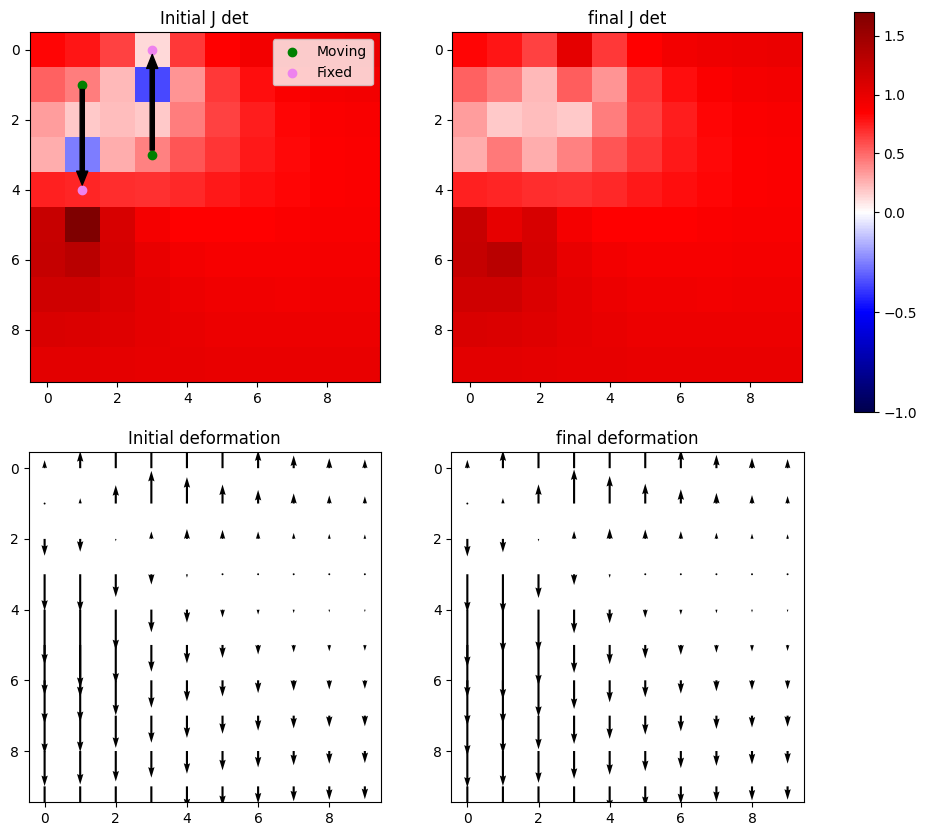

In [102]:
msample = np.array([
    [0, 1, 1],
    [0, 3, 3],
])
fsample = np.array([
    [0, 4, 1],
    [0, 0, 3],
])

fixed_sample = np.zeros((1, 10, 10))
#test_grad(fixed_sample, msample, fsample)
#test_scipy(fixed_sample, msample, fsample)
run_lapl_and_correction(fixed_sample, msample, fsample)

deformation shape: (3, 1, 10, 10)
deformation_i shape: (3, 1, 10, 10), phi_init shape: (2, 10, 10)
Reduced to 0 from 0 -ve jacobians.
Deviation 0.0 in 0.0025467872619628906s
Number of negative jacobians per iteration: [0]
            x-def          y-def       jacobian          
              min      max   min  max       min       max
initial -3.999719 -0.99993   0.0  0.0  0.008381  1.445456
final   -3.999719 -0.99993   0.0  0.0  0.008381  1.445456
meshgrid shape for plot: (10, 10)


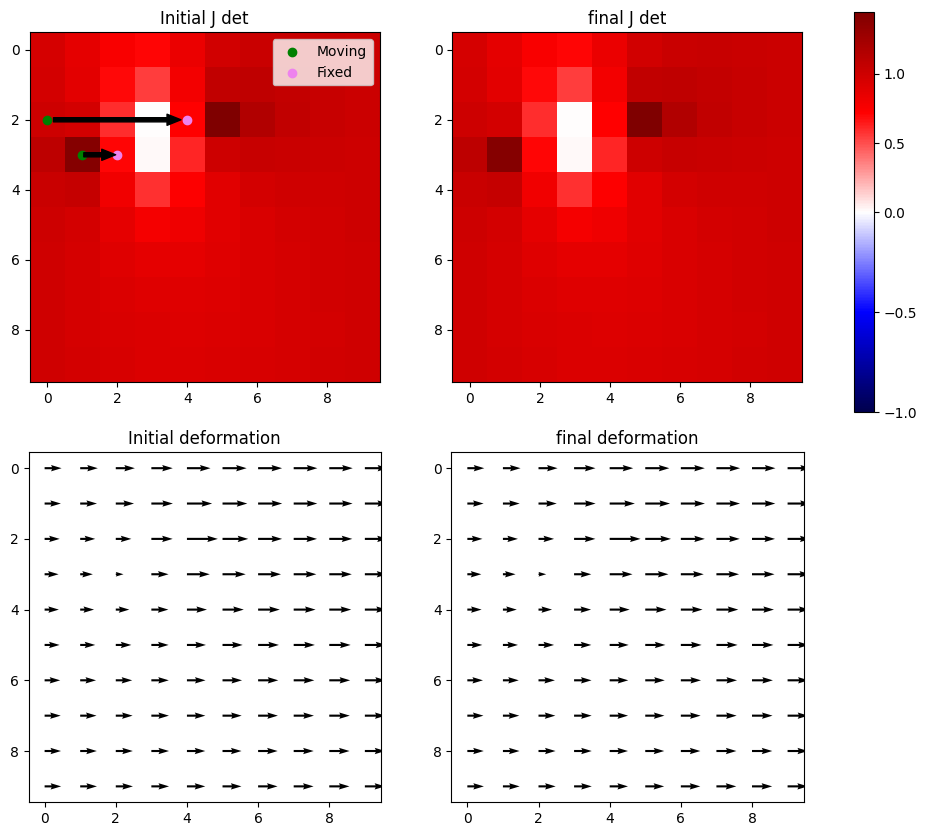

In [103]:
msample = np.array([
    [0, 2, 0],
    [0, 3, 1],
])
fsample = np.array([
    [0, 2, 4],
    [0, 3, 2],
])

fixed_sample = np.zeros((1, 10, 10))
#test_grad(fixed_sample, msample, fsample)
#test_scipy(fixed_sample, msample, fsample)
#red_test_scipy(fixed_sample, msample, fsample)
run_lapl_and_correction(fixed_sample, msample, fsample)

(15, 3) (15, 3)
deformation shape: (3, 1, 20, 40)
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 114 from 129 -ve jacobians.
Deviation 24.041413634264778 in 0.11943197250366211s
Number of negative jacobians per iteration: [129, 128, 128, 128, 128, 127, 126, 125, 124, 123, 123, 122, 122, 121, 121, 120, 120, 120, 120, 121, 121, 120, 120, 119, 118, 118, 118, 117, 117, 117, 117, 116, 116, 116, 116, 115, 115, 115, 115, 116, 116, 116, 116, 116, 116, 115, 114, 114, 114, 114, 114]
             x-def            y-def            jacobian          
               min        max   min       max       min       max
initial -13.002136  29.004766   0.0  1.000051 -5.157539  8.077514
final    -8.458294  17.383562   0.0  0.665450 -1.605972  3.281548
meshgrid shape for plot: (20, 40)


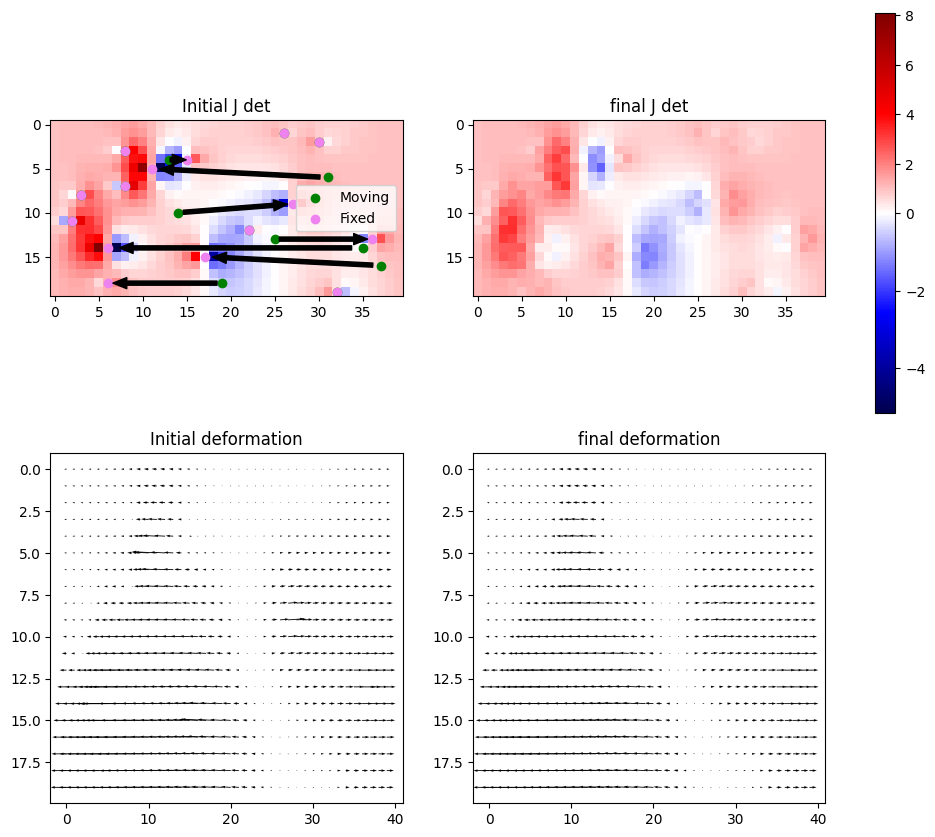

In [104]:
# data analysis

# Create sample set of points
mpoints_path = "../data/corrected_correspondences_count_touching/mpoints.npy"
fpoints_path = "../data/corrected_correspondences_count_touching/fpoints.npy"

mpoints, fpoints = correspondences.downsample_points(mpoints_path, fpoints_path, debug=False)
#print(mpoints.shape, fpoints.shape) 

fixed_sample = np.zeros((1, 20, 40))

# z values in mpoints, fpoints are for 3 slices numbered 0,1,2
slice_no = 1

# use 
mask = mpoints[:,0]==slice_no
new_mpoints = mpoints[mask].copy()
new_mpoints[:,0] = 0

mask = fpoints[:,0]==slice_no
new_fpoints = fpoints[mask].copy()
new_fpoints[:,0] = 0

print(new_mpoints.shape, new_fpoints.shape)


#test_grad(fixed_sample, msample, fsample)
#red_test_scipy(fixed_sample, new_mpoints[:5], new_fpoints[:5])
run_lapl_and_correction(fixed_sample, new_mpoints, new_fpoints)

## Real slice

(3, 528, 320, 456)
(3, 1, 320, 456)
(13, 3) (13, 3)
deformation_i shape: (3, 1, 320, 456), phi_init shape: (2, 320, 456)
Reduced to 432 from 508 -ve jacobians.
Deviation 46.300433420889014 in 1.5840771198272705s
            x-def               y-def             jacobian           
              min       max       min       max        min        max
initial -9.000998  9.000998 -7.999996  8.999995 -11.264728  17.758509
final   -9.000998  9.000998 -7.999996  8.999995  -3.583674   9.272665
meshgrid shape for plot: (320, 456)


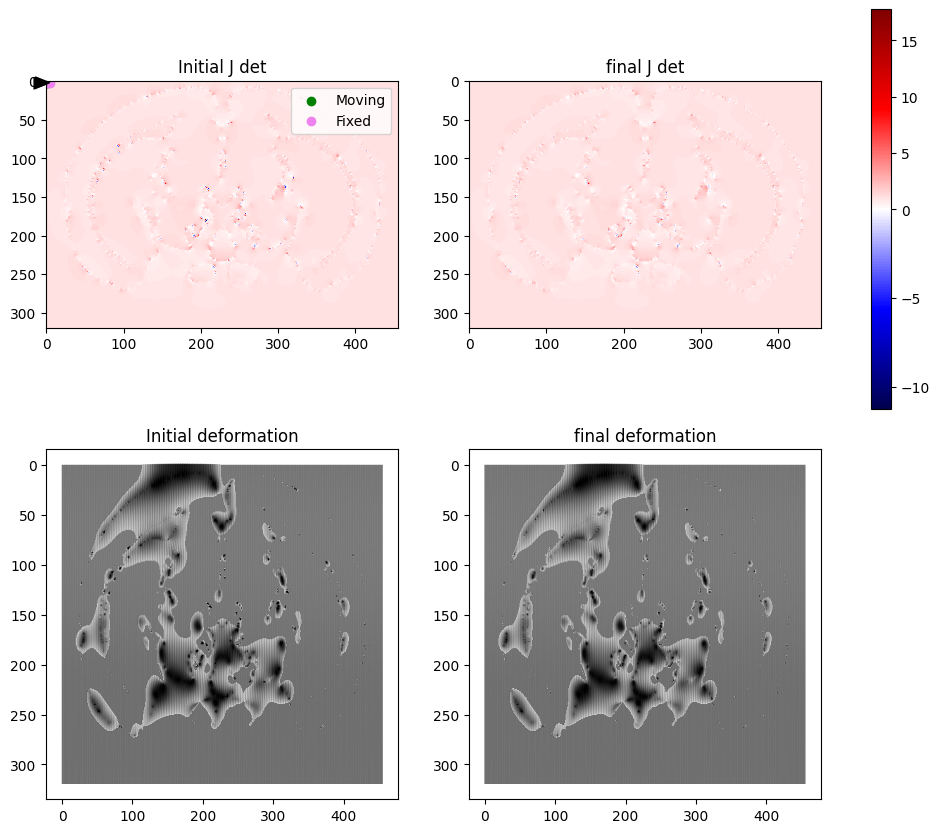

In [121]:
# data analysis

# Create sample set of points
mpoints_path = "../data/corrected_correspondences_count_touching/mpoints.npy"
fpoints_path = "../data/corrected_correspondences_count_touching/fpoints.npy"

mpoints, fpoints = correspondences.downsample_points(mpoints_path, fpoints_path, debug=False)
#print(mpoints.shape, fpoints.shape) 

deformation_field_path = "../data/base_unique_correspondences/registered_output/deformation3d.npy"
deformation_field = np.load(deformation_field_path)

# select a slice
def_shape = deformation_field.shape
print(def_shape)
deformation_i = deformation_field[:, 349].reshape((def_shape[0], 1, def_shape[2], def_shape[3]))
print(deformation_i.shape)
# z values in mpoints, fpoints are for 3 slices numbered 0,1,2
slice_no = 0

# use 
mask = mpoints[:,0]==slice_no
new_mpoints = mpoints[mask].copy()
new_mpoints[:,0] = 0

mask = fpoints[:,0]==slice_no
new_fpoints = fpoints[mask].copy()
new_fpoints[:,0] = 0

print(new_mpoints.shape, new_fpoints.shape)

phi_corrected, jacobians, num_neg_jac_per_iter = correct_using_heuristic(deformation_i)
#plot_jacobians_iteratively(jacobians, msample, fsample, methodName='SLSQP')
plot_deformations(msample, fsample, deformation_i, phi_corrected, figsize=(10,10))
# kept running for 450min

## Make more testcases

In [136]:
# make testcases

def extract_valid_grids(deformation_i, jacobian_init, grid_h=20, grid_w=40, num_grids=20):
    _, _, H, W = deformation_i.shape
    grids = []
    indices = []

    # Divide the image into non-overlapping blocks
    for y in range(0, H, grid_h//2):
        for x in range(0, W, grid_w//2):
            if y + grid_h > H or x + grid_w > W:
                continue  # skip incomplete edge blocks

            # Check if this patch contains any negative Jacobian
            patch_jacobian = jacobian_init[y:y+grid_h, x:x+grid_w]
            if (patch_jacobian < 0).any():
                patch_def = deformation_i[:, :, y:y+grid_h, x:x+grid_w]
                grids.append(patch_def)
                indices.append((y, x))

                if len(grids) == num_grids:
                    break
        if len(grids) == num_grids:
            break

    if len(grids) < num_grids:
        #raise ValueError(f"Only found {len(grids)} valid grids with negative Jacobians. Try relaxing constraints or increasing overlap.")
        print(f"Only found {len(grids)} valid grids with negative Jacobians. Try relaxing constraints or increasing overlap.")

    # Stack into a single array of shape (20, 3, 1, 20, 40)
    all_grids = np.stack(grids)

    # Save the grids and their (y,x) start positions
    np.savez('valid_grids.npz', deformation_grids=all_grids, grid_indices=np.array(indices))

    print(f"Saved {len(grids)} grids to valid_grids.npz")

In [137]:
deformation_field_path = "../data/base_unique_correspondences/registered_output/deformation3d.npy"
deformation_field = np.load(deformation_field_path)

# select a slice
def_shape = deformation_field.shape
print(def_shape)
deformation_i = deformation_field[:, 351].reshape((def_shape[0], 1, def_shape[2], def_shape[3]))
print(deformation_i.shape)
jacobian_init = jacobian_det2D(deformation_i[1:])
extract_valid_grids(deformation_i, jacobian_init)

(3, 528, 320, 456)
(3, 1, 320, 456)
Only found 14 valid grids with negative Jacobians. Try relaxing constraints or increasing overlap.
Saved 14 grids to valid_grids.npz


### Load and use testcases

TESTING GRID 1
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 0 -ve jacobians.
Deviation 0.0 in 0.0025076866149902344s
        x-def      y-def           jacobian          
          min  max   min       max      min       max
initial   0.0  0.0   0.0  0.008111      1.0  1.002905
final     0.0  0.0   0.0  0.008111      1.0  1.002905
meshgrid shape for plot: (20, 40)


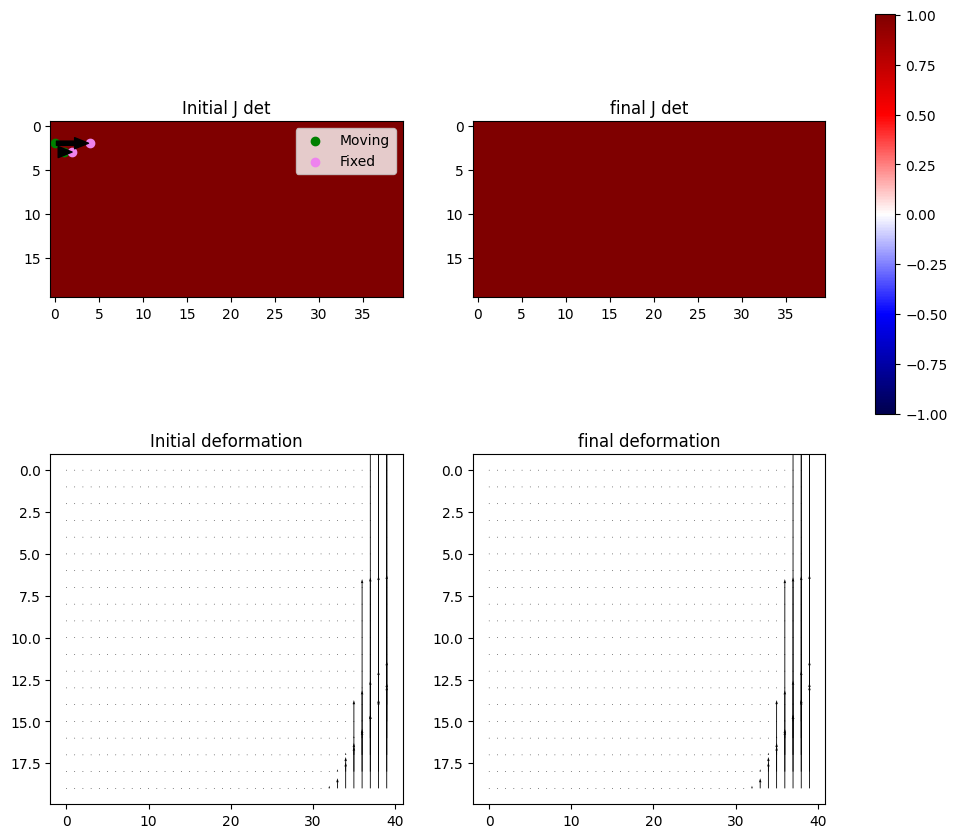

TESTING GRID 2
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 0 -ve jacobians.
Deviation 0.0 in 0.002727031707763672s
        x-def          y-def           jacobian          
          min      max   min       max      min       max
initial   0.0  0.00094   0.0  0.265464      1.0  1.025257
final     0.0  0.00094   0.0  0.265464      1.0  1.025257
meshgrid shape for plot: (20, 40)


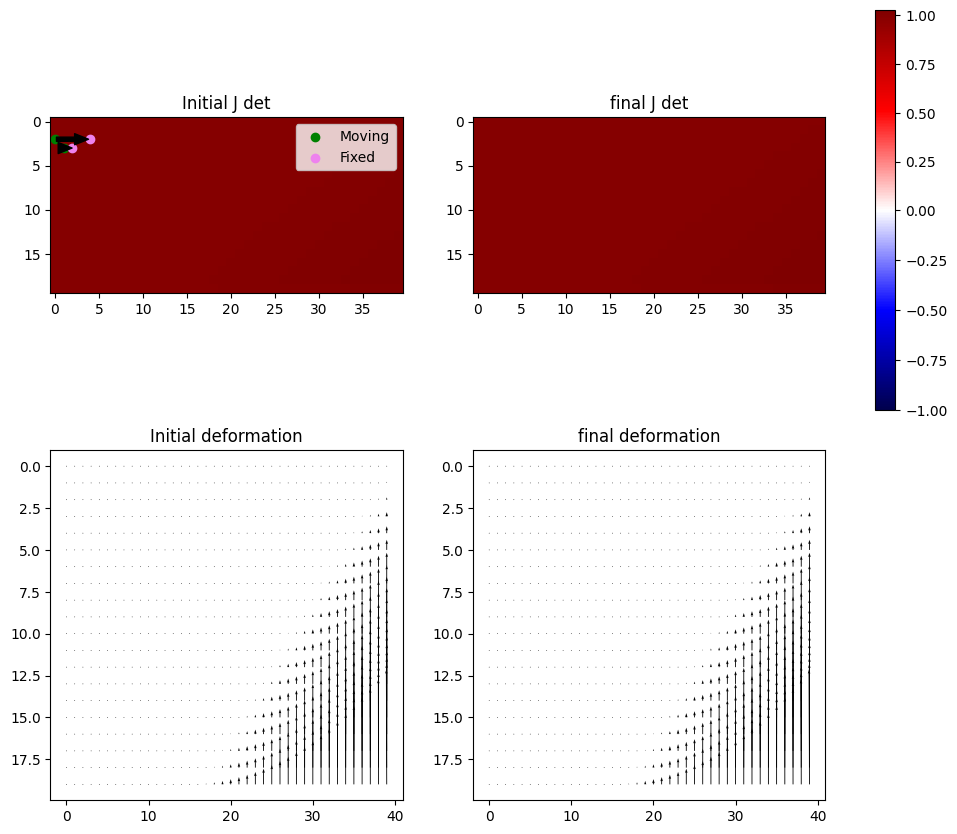

TESTING GRID 3
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 0 -ve jacobians.
Deviation 0.0 in 0.003770112991333008s
        x-def                   y-def           jacobian          
          min       max           min       max      min       max
initial   0.0  0.117825  2.372286e-19  0.990309      1.0  1.067007
final     0.0  0.117825  2.372286e-19  0.990309      1.0  1.067007
meshgrid shape for plot: (20, 40)


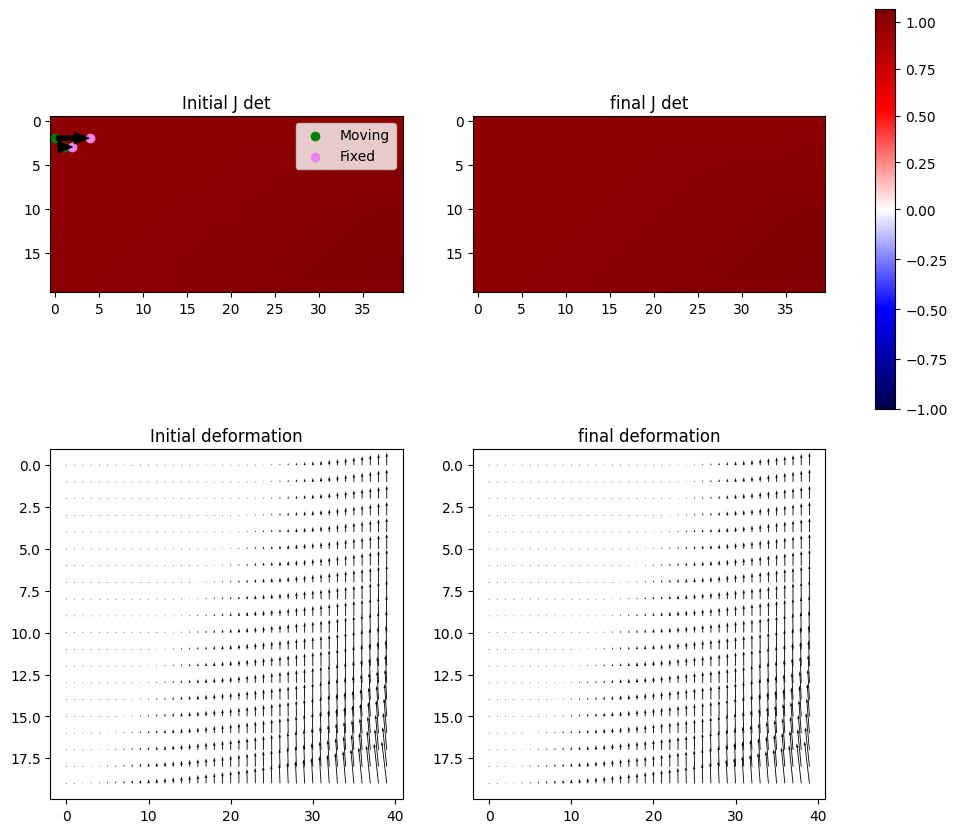

TESTING GRID 4
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 0 -ve jacobians.
Deviation 0.0 in 0.002177000045776367s
        x-def               y-def           jacobian          
          min       max       min      max       min       max
initial   0.0  0.473821  0.002778  2.17067  1.000948  1.102934
final     0.0  0.473821  0.002778  2.17067  1.000948  1.102934
meshgrid shape for plot: (20, 40)


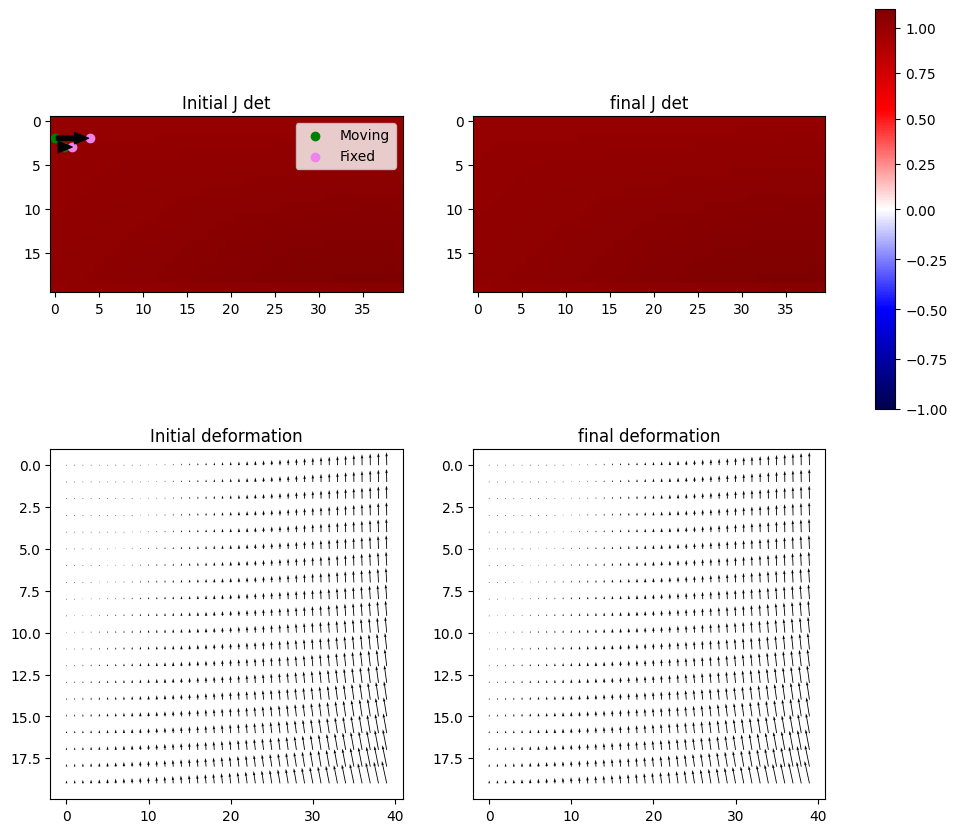

TESTING GRID 5
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 0 -ve jacobians.
Deviation 0.0 in 0.0025408267974853516s
            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial  0.000002  0.742604  0.326605  4.103956  1.001288  1.114569
final    0.000002  0.742604  0.326605  4.103956  1.001288  1.114569
meshgrid shape for plot: (20, 40)


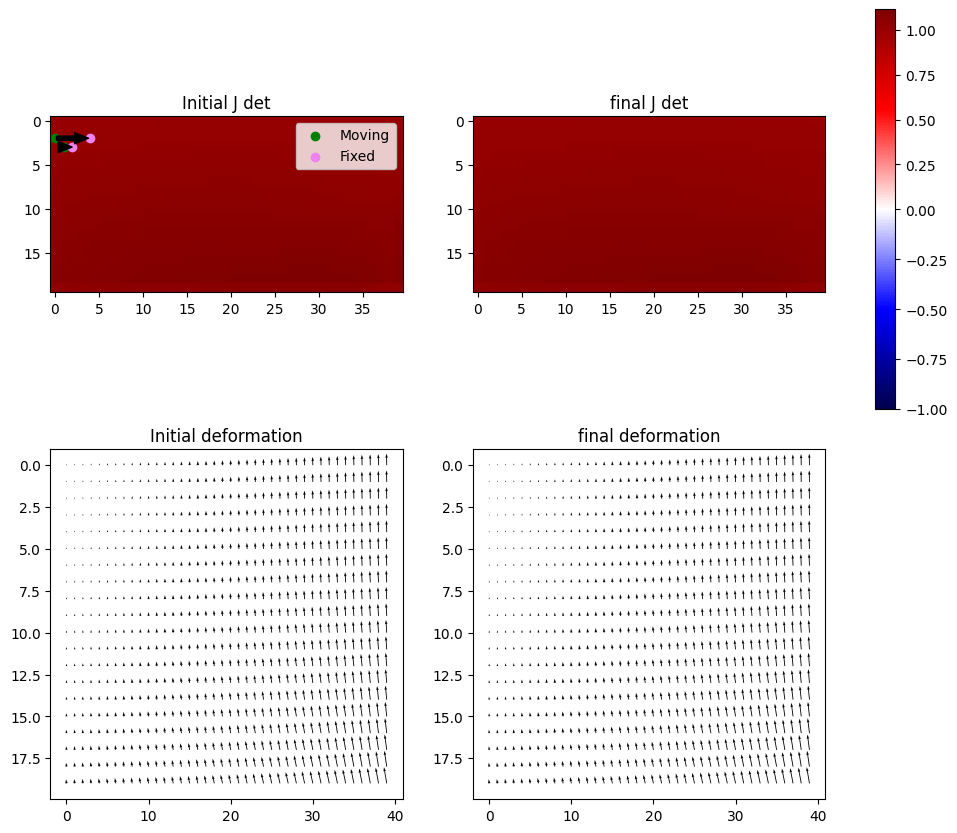

TESTING GRID 6
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 3 -ve jacobians.
Deviation 4.5545040117773965 in 0.0038688182830810547s
            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial -6.000665  0.742604  1.324829  8.999995 -1.066136  2.185311
final   -2.261594  0.742604  1.324829  7.354260  0.612465  1.646680
meshgrid shape for plot: (20, 40)


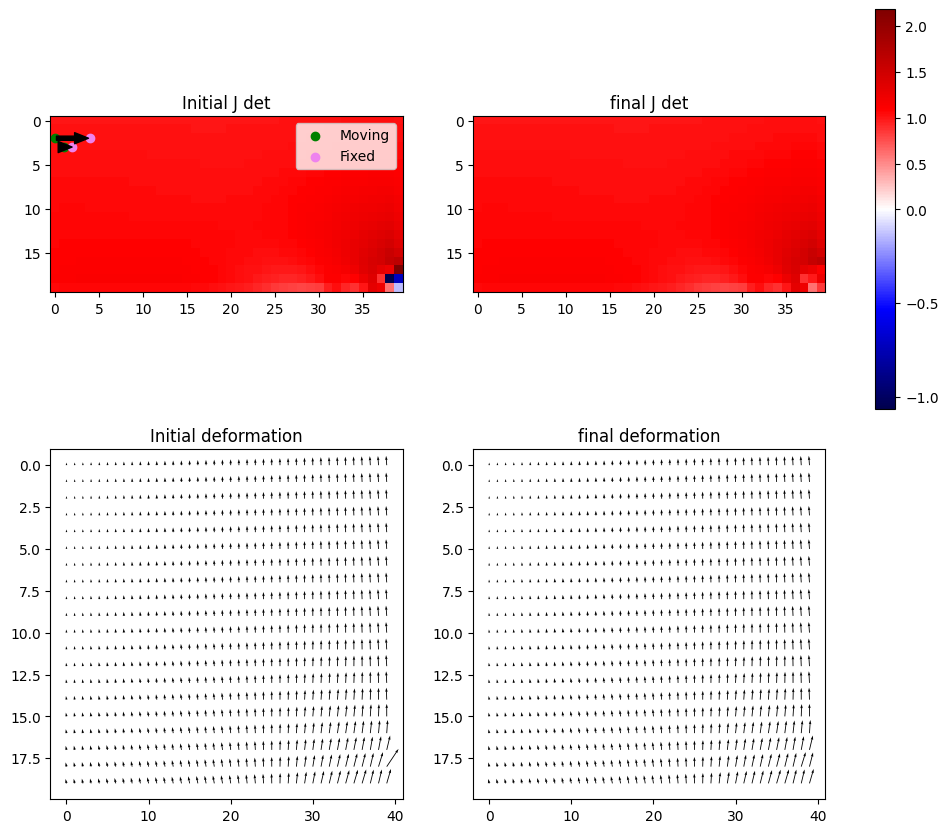

TESTING GRID 7
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 5 -ve jacobians.
Deviation 9.019599870751088 in 0.02449798583984375s
            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial -6.000665  8.000887  3.003603  8.999995 -2.138405  5.935787
final   -2.261594  2.631215  3.003603  7.475158  0.000750  3.181262
meshgrid shape for plot: (20, 40)


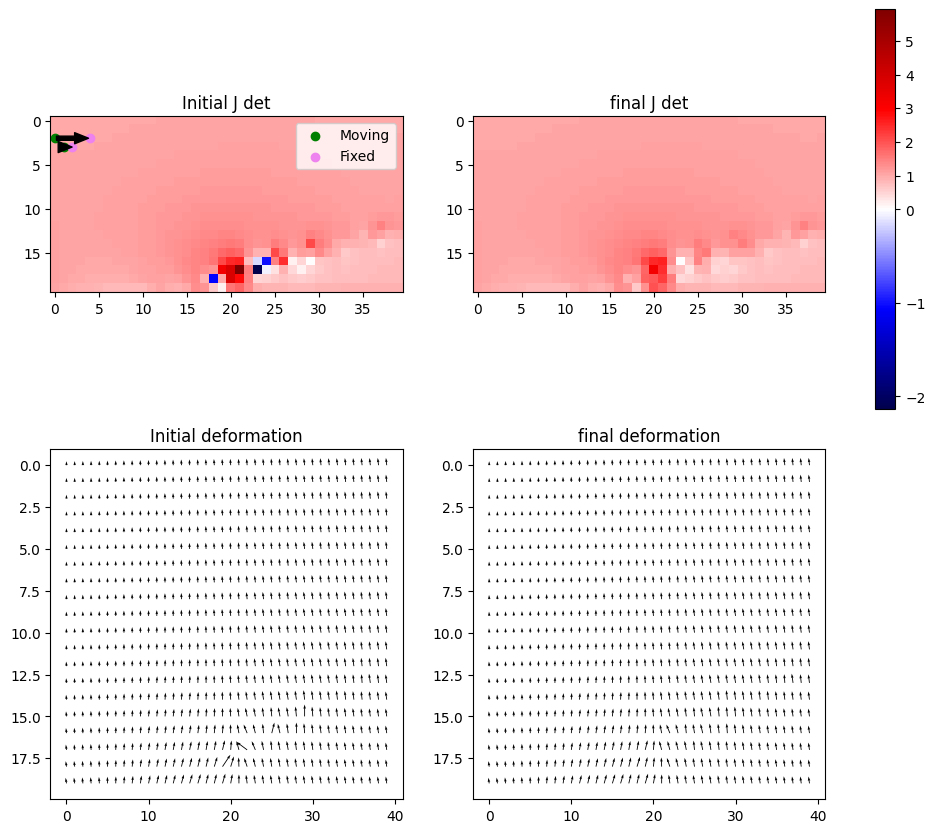

TESTING GRID 8
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 8 -ve jacobians.
Deviation 9.822774929886714 in 0.028958797454833984s
            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial -4.000443  8.000887  4.728536  8.999995 -2.138405  5.935787
final   -1.225210  2.746101  4.728536  7.475158  0.000750  2.585509
meshgrid shape for plot: (20, 40)


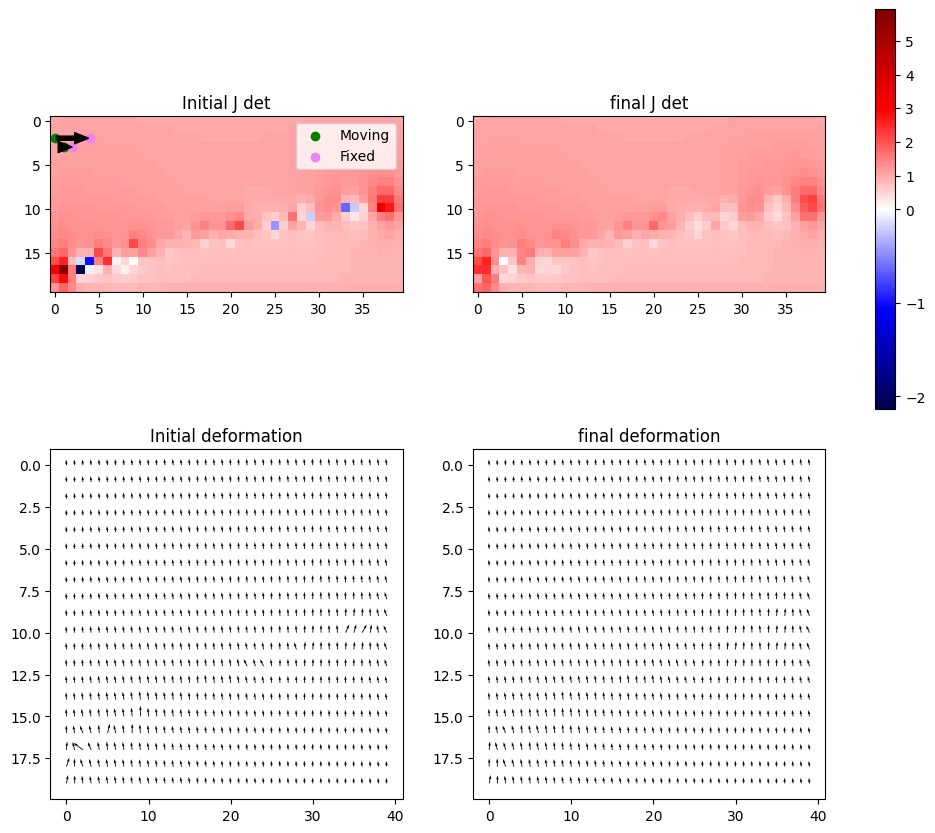

TESTING GRID 9
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 5 -ve jacobians.
Deviation 6.083164494383401 in 0.022719383239746094s
            x-def               y-def           jacobian          
              min       max       min       max      min       max
initial -4.000443  4.166723  4.449782  7.034078 -0.62638  3.497495
final   -0.587818  3.105151  4.449782  6.999996  0.27491  2.253294
meshgrid shape for plot: (20, 40)


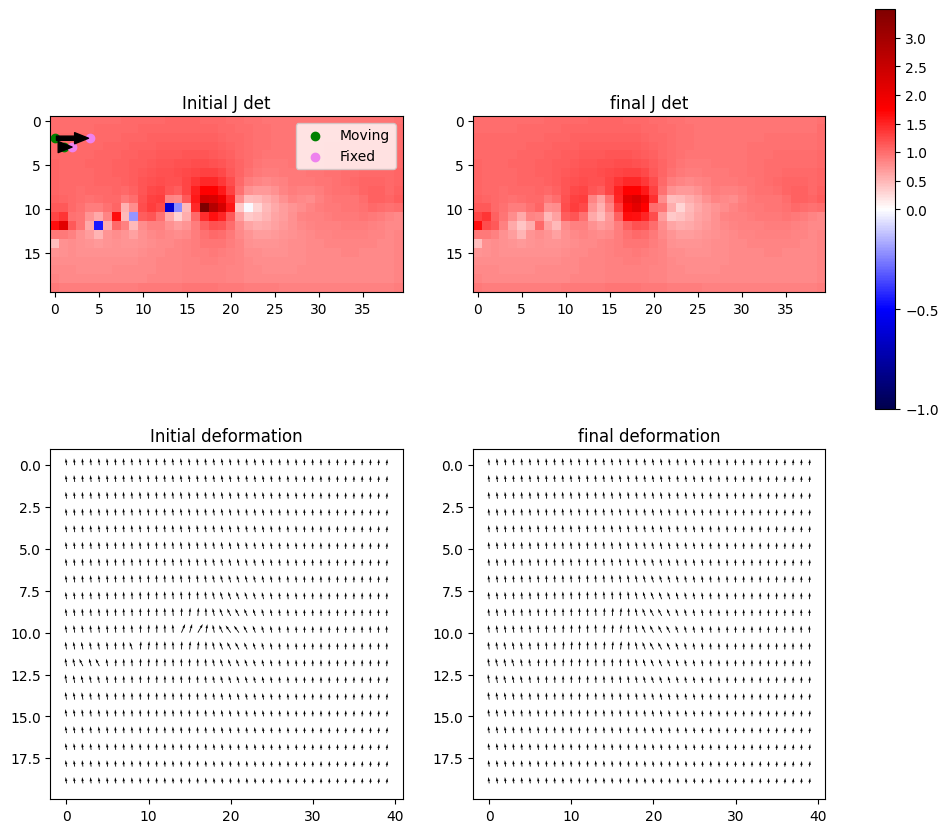

TESTING GRID 10
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 1 -ve jacobians.
Deviation 1.0909105258922807 in 0.004049062728881836s
            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial -3.015054  4.166723  3.148323  7.692756 -0.011955  2.377863
final   -3.015054  4.166723  3.148323  7.692756  0.274910  2.377863
meshgrid shape for plot: (20, 40)


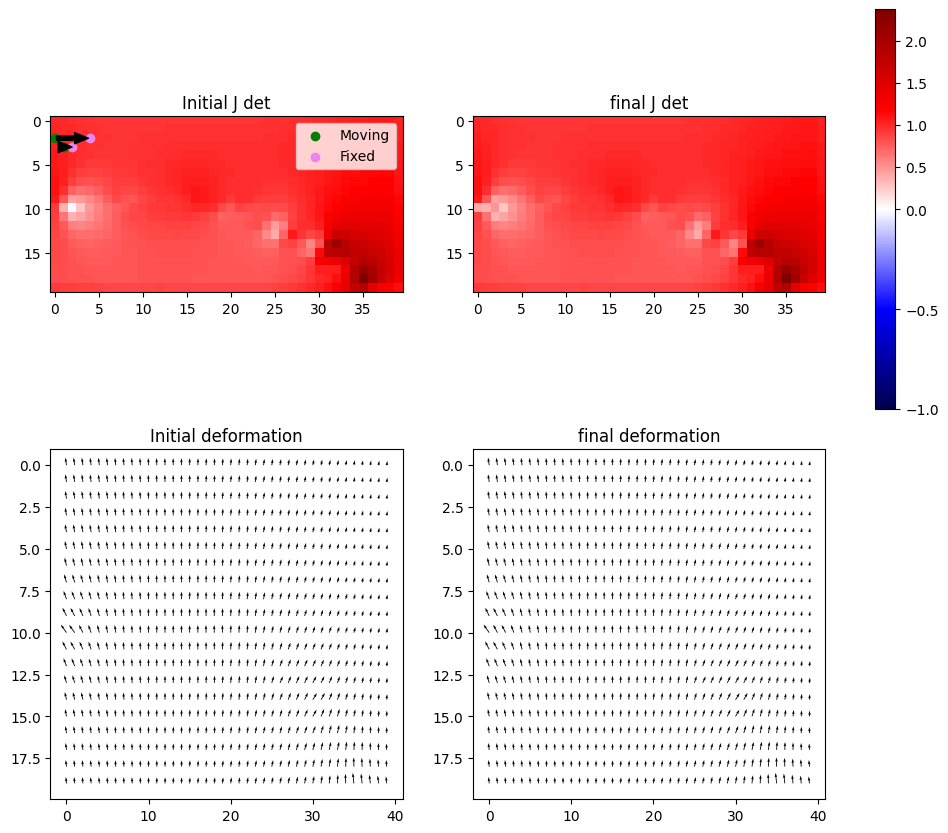

TESTING GRID 11
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 0 -ve jacobians.
Deviation 0.0 in 0.0042819976806640625s
            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial -3.015054  2.994455 -0.255609  7.692756  0.397486  2.377863
final   -3.015054  2.994455 -0.255609  7.692756  0.397486  2.377863
meshgrid shape for plot: (20, 40)


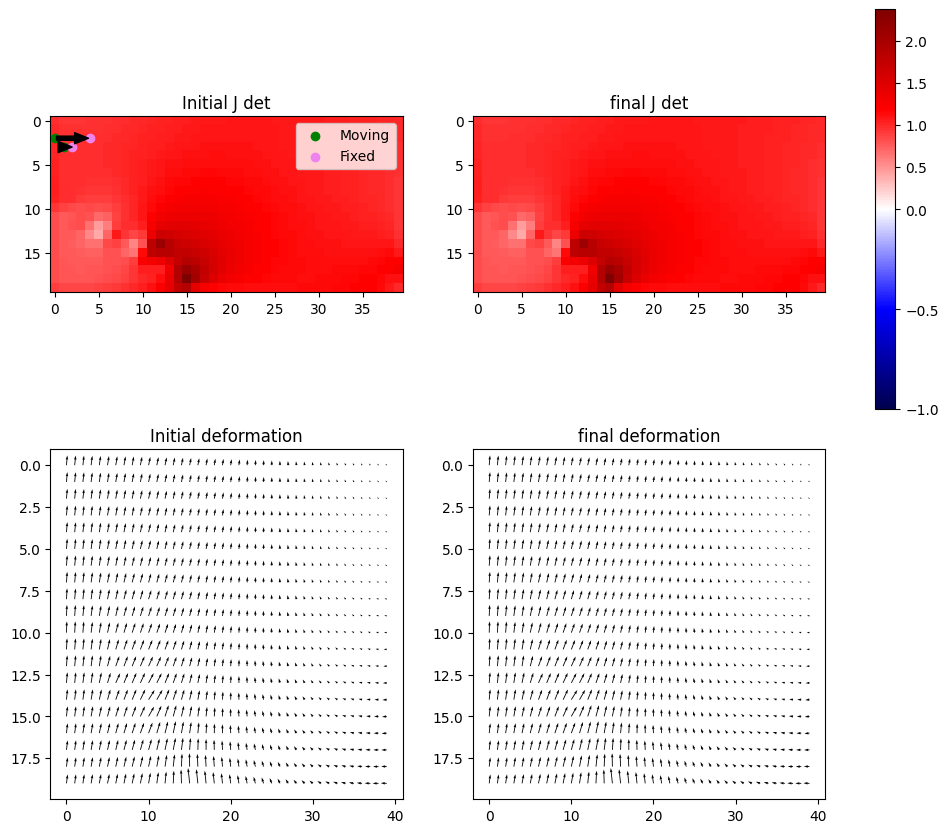

TESTING GRID 12
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 1 -ve jacobians.
Deviation 5.382869162724444 in 0.005358219146728516s
            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial -1.000111  4.000443 -2.999998  4.999997 -0.097546  4.692159
final   -1.000111  4.000443 -2.999998  4.580547  0.058913  2.530451
meshgrid shape for plot: (20, 40)


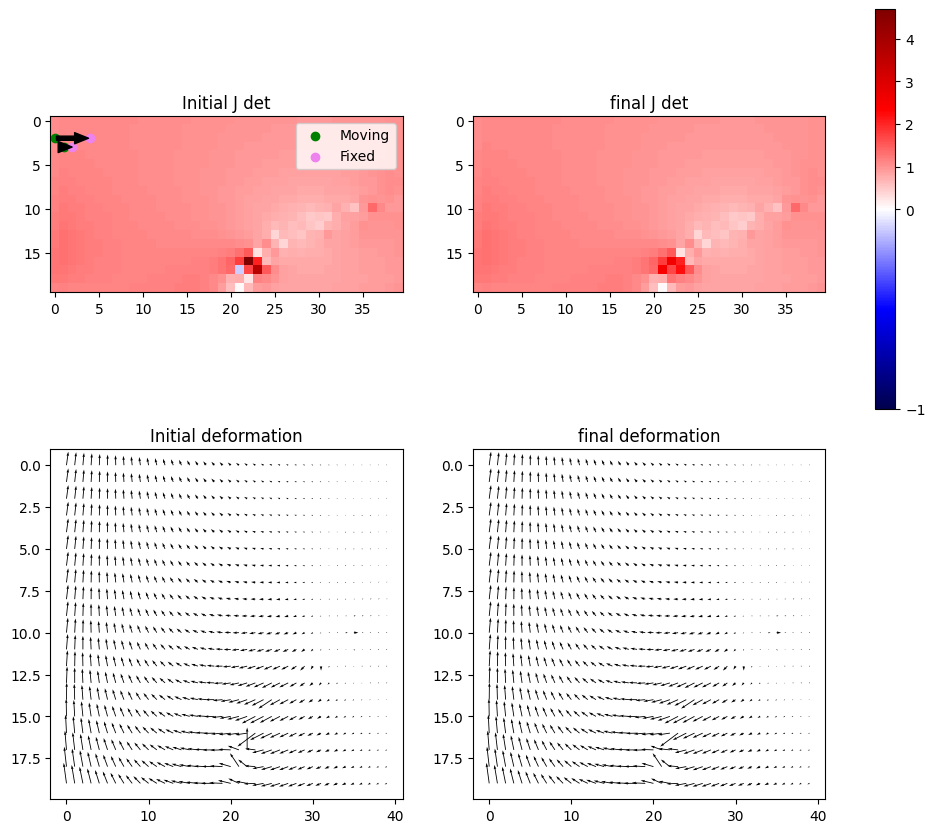

TESTING GRID 13
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 1 -ve jacobians.
Deviation 5.382869162724444 in 0.005270957946777344s
            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial -1.000111  4.000443 -2.999998  4.999997 -0.097546  4.692159
final   -1.000111  4.000443 -2.999998  2.999998  0.058913  2.530451
meshgrid shape for plot: (20, 40)


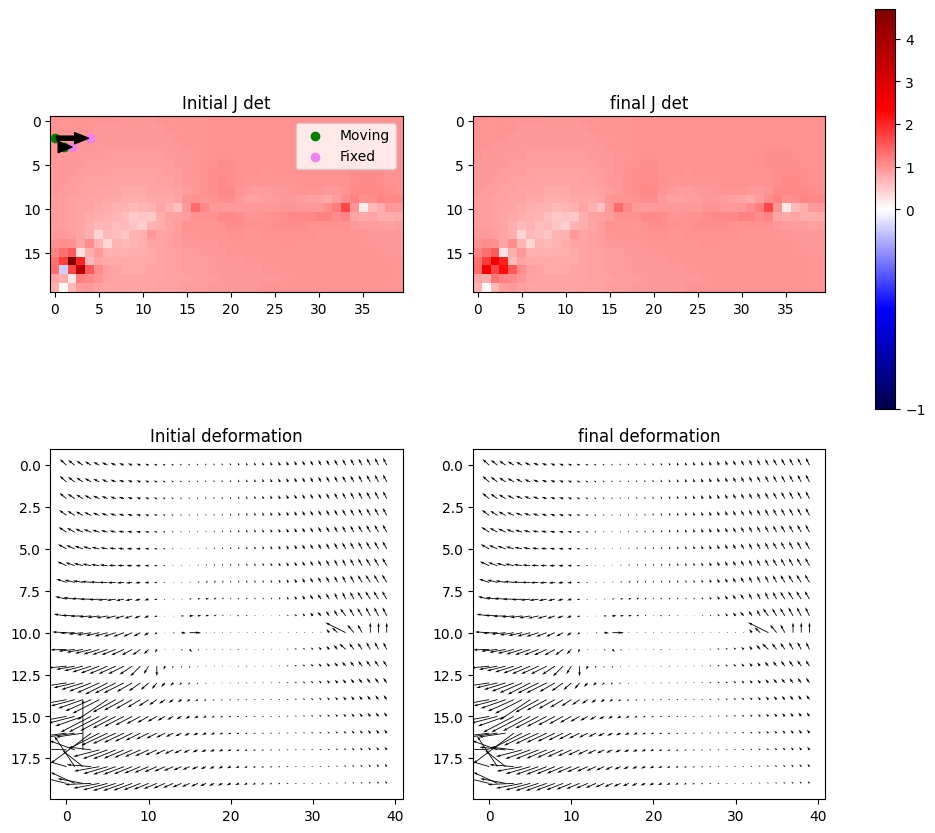

TESTING GRID 14
deformation_i shape: (3, 1, 20, 40), phi_init shape: (2, 20, 40)
Reduced to 0 from 2 -ve jacobians.
Deviation 4.163132825513046 in 0.006557941436767578s
            x-def               y-def            jacobian          
              min       max       min       max       min       max
initial -4.000443  3.000333 -0.196801  1.999999 -0.931843  2.893842
final   -0.869662  2.000222 -0.196801  1.999999  0.203445  1.706245
meshgrid shape for plot: (20, 40)


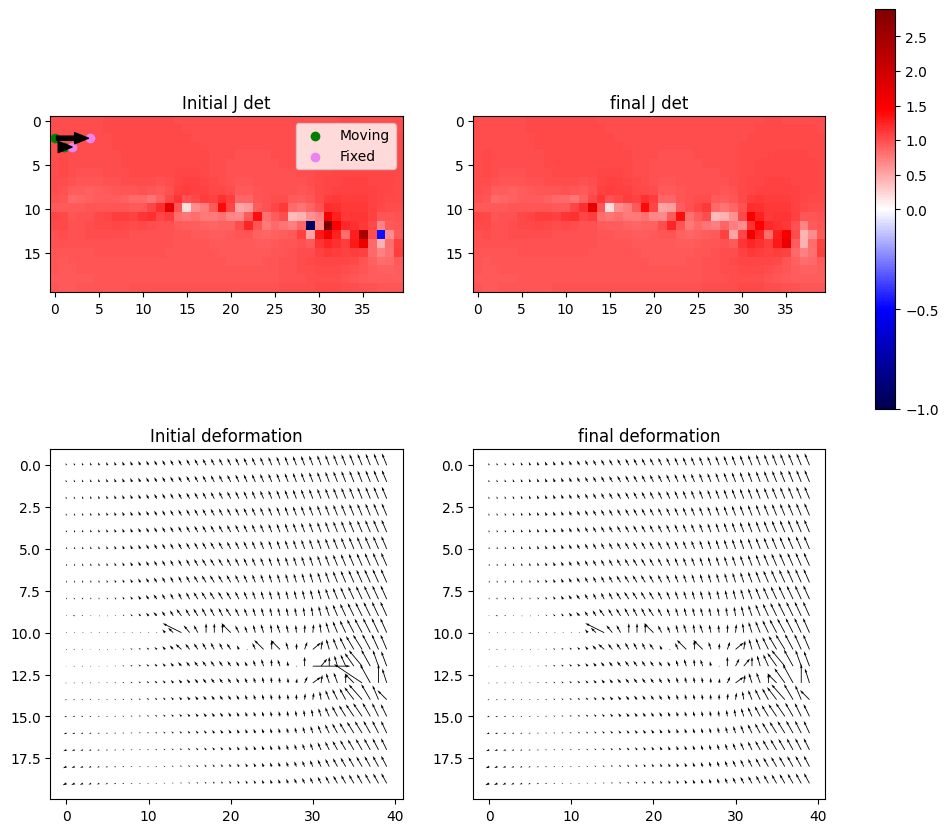

In [138]:
data = np.load('valid_grids.npz')
grids = data['deformation_grids']     # shape: (20, 3, 1, 20, 40)
grid_indices = data['grid_indices']   # shape: (20, 2)

ind = 1

for deformation_i in grids:
    print(f'TESTING GRID {ind}')
    ind += 1
    phi_corrected, jacobians, num_neg_jac_per_iter = correct_using_heuristic(deformation_i)
    #plot_jacobians_iteratively(jacobians, msample, fsample, methodName='SLSQP')
    plot_deformations(msample, fsample, deformation_i, phi_corrected, figsize=(10,10))

## Jdet function testing

In [139]:
# global val list
print(list_dev)
print('===')
print(num_neg_jac)
print('=====')
print(time_taken)

# L2
list_dev_L2 = [2.680895253076589, 69.80633869969029, 9.418067274643581, 69.80633869969029, 5.197075330527052, 1.8231005476373714, 2.2589086079637837, 2.8612431766103588, 0.0, 27.945036523729176]

num_neg_jac_init_L2 = [12, 158, 28, 158, 29, 5, 3, 2, 0, 129]

num_neg_jac_L2 = [0, 132, 15, 132, 0, 0, 0, 0, 0, 115]

# L2s
list_dev_L2s = [4.768607942055218, 26.252278493509536, 10026.7948106916, 26.252278493509536, 9.104921565888146, 2.379737612461383, 3.019209538644817, 3.1687868005130904, 0.0, 25.14703328621248]

num_neg_jac_L2s = [0, 137, 15, 137, 0, 0, 0, 0, 0, 109]

# L1

list_dev_L1 = [3.1452826411439276, 49.78213374285741, 12.373348412316172, 49.78213374285741, 12.224721045040889, 2.2478387386726184, 2.419587408528433, 3.1974909624498786, 0.0, 22.553299646732658]

num_neg_jac_L1 = [0, 135, 7, 135, 2, 0, 0, 0, 0, 106]

# L1s
list_dev_L1s = [3.8200316274887136, 27.98726389799386, 11.400909181236925, 27.98726389799386, 7.421816327869949, 2.3274873804728444, 2.952056050877296, 3.112671741644684, 0.0, 21.352944007229933]

num_neg_jac_L1s = [0, 132, 11, 132, 0, 0, 0, 0, 0, 110]

#L2wr
list_dev_L2wr = [1.3388562022484387e-06, 2.1911745978666906, 0.5583311141489217, 2.1911745978666906, 0.00010905921377629281, 8.880030350916757e-08, 8.065887478278329e-07, 8.93188013674346e-08, 0.0, 1.4515563532878142]

num_neg_jac_L2wr = [12, 156, 27, 156, 29, 5, 3, 2, 0, 125]

#L1wr - this
list_dev_L1wr = [1.8719204800182033e-05, 2.800815958456984, 0.6335240860765275, 2.800815958456984, 0.01548376720517454, 3.821057987703311e-05, 2.2714245365299625e-05, 3.223513937255436e-05, 0.0, 2.2229220010626967]

num_neg_jac_L1wr = [12, 156, 29, 156, 29, 5, 3, 2, 0, 123]

#L2swr
list_dev_L2swr = [6.347496024011014, 6.0603622126465195, 8.073554663868867, 6.0603622126465195, 9.805082662138908, 2.4315062468207964, 3.329061274139249, 1.7311478095318673, 0.0, 19.893147478504304]

num_neg_jac_L2swr = [0, 162, 30, 162, 6, 0, 0, 0, 0, 127]
tt_L2swr = [[1.0550048351287842, 15.897326946258545, 5.623910903930664, 16.062530040740967, 12.120941877365112, 0.3773469924926758, 0.3408081531524658, 0.3339860439300537, 0.15784001350402832, 8.772908926010132]
]
ttt_L2swr = 71.68918776512146

#L1swr
list_dev_L1swr = [3.300356140988371, 5.219200883030088, 3.8569020877225846, 5.219200883030088, 4.37866602840255, 1.4021137590566208, 2.0081703705493297, 1.228014013747989, 0.0, 11.192059918711248]

num_neg_jac_L1swr = [11, 156, 28, 156, 19, 4, 3, 0, 0, 121]
tt_L1swr = [38.703429222106934, 85.19641089439392, 57.048078775405884, 85.34915089607239, 37.369688749313354, 21.995036840438843, 18.338409185409546, 3.49845290184021, 0.16025185585021973, 81.12396311759949]

ttt_L1swr = 437.7158851623535

full_end = time.time()
print("time taken is", full_end-full_start)

[6.209310047336316, 12.948552191012604, 9.486152754473682, 12.948552191012604, 11.185462304919913, 2.960600589754988, 3.2708004766479815, 2.267238330667547, 0.0, 24.041413634264778, 46.300433420889014, 0.0, 0.0, 0.0, 7.066318103831316, 6.859159677615413, 0.0, 3.0725169962814256, 3.0725169962814256, 3.0725169962814256, 3.0725169962814256, 3.0725169962814256, 46.300433420889014, 0.0, 0.0, 0.0, 7.066318103831316, 6.859159677615413, 0.0, 3.0725169962814256, 3.0725169962814256, 0.0, 0.0, 0.0, 0.0, 0.0, 4.456283647395103, 7.066318103831316, 8.158557052765765, 6.859159677615413, 3.5857935057260617, 0.0, 0.0, 3.0725169962814256, 4.567442409929053, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.9195383026607689, 7.952574582547422, 8.404998193426794, 5.276052911639507, 4.092866341637556, 0.0, 0.0, 3.56843625908785, 0.0, 0.0, 0.0, 0.0, 0.0, 4.5545040117773965, 9.019599870751088, 9.822774929886714, 6.083164494383401, 1.0909105258922807, 0.0, 5.382869162724444, 5.382869162724444, 4.163132825513046]
===
[0, 150, 1